In [19]:
import napari
from numpy import spacing
from skimage.io import imread
import glob
from wip_util import zero_pad_index, smap_csv_to_emitters
import numpy as np
import pandas as pd
from torch import chunk
import decode
from wip_util import get_np_points, reverse_emitters
import os

start_iter = 645
end_iter = 647
chunk_string = f"{zero_pad_index(start_iter, 4)}-{zero_pad_index(end_iter, 4)}"
frames_per_iter = 250

start_frame = start_iter * frames_per_iter
end_frame = end_iter * frames_per_iter

frames_path = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
#frame_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/frames/'
out_path = r'D:\Janelia_slm_data\Janelia PALM RUN2'
fig_path = out_path

if not os.path.exists(fig_path):
    os.makedirs(fig_path)


In [20]:
def load_frames(id):
    print(f"loading frames for id: {id}")
    frames_pattern = rf'{frames_path}\3dpalm488nm_iter_{zero_pad_index(id, 4)}_0001_ch0_cam1_stack0000_405nm_0000000msec_*msecabs_000x_000y_000z_0001t.tif'
    frames_name = glob.glob(frames_pattern)
    if frames_name:
        return imread(frames_name[0])
    else:
        print(f"no frames found for id: {id}")
        return None

frames = np.concatenate([load_frames(i) for i in range(start_iter, end_iter + 1)], axis=0)

print(f"Loaded frames shape: {frames.shape}")

loading frames for id: 645
loading frames for id: 646
loading frames for id: 647
Loaded frames shape: (750, 800, 800)


In [21]:
viewer = napari.Viewer()
viewer.add_image(frames, name='frames')

<Image layer 'frames' at 0x173135ab400>

In [22]:
hesslab_input_file = r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
hesslab_emitters=decode.EmitterSet.load(hesslab_input_file)
print(hesslab_emitters)
hesslab_emitters = hesslab_emitters[(hesslab_emitters.frame_ix >= start_frame) & (hesslab_emitters.frame_ix < end_frame)]
hesslab_emitters.frame_ix = hesslab_emitters.frame_ix - start_frame
print(hesslab_emitters)

EmitterSet
::num emitters: 41570847
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 289749
::spanned volume: [ 2.32811e-01  1.93751e-01 -8.00000e+02] - [800.    799.475 600.   ]
EmitterSet
::num emitters: 49567
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [  15.0408     2.68076 -799.951  ] - [799.434 796.218 599.764]


In [23]:
hesslab_points = get_np_points(hesslab_emitters, 0, 1000)
hesslab_points[:, [1,2]] = hesslab_points[:, [2,1]]  # swap x and y for napari
viewer.add_points(hesslab_points, name='hesslab points', face_color='blue', size=5, symbol='x')

<Points layer 'hesslab points' at 0x1730034afd0>

In [24]:
print(hesslab_emitters)

EmitterSet
::num emitters: 49567
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [  15.0408     2.68076 -799.951  ] - [799.434 796.218 599.764]


In [25]:
from wip_util import load_iter_results

iter_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27'
iter_path = r'E:\processed-2025-06-27'

decode_emitters = load_iter_results(iter_path, 645, 647)

Loading iterations: 100%|██████████| 2/2 [00:00<00:00, 66.67it/s]


In [26]:
print(decode_emitters)
decode_emitters.frame_ix = decode_emitters.frame_ix - start_frame 
print(decode_emitters)

EmitterSet
::num emitters: 345830
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 161250 - 161749
::spanned volume: [-4.5627666e-01 -6.3932061e-01 -1.2588881e+03] - [ 799.507   799.4638 1246.2266]
EmitterSet
::num emitters: 345830
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [-4.5627666e-01 -6.3932061e-01 -1.2588881e+03] - [ 799.507   799.4638 1246.2266]


In [27]:
sigma_x_high_threshold = 40
sigma_z_high_threshold = 150

em_sub = decode_emitters[
    (decode_emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (decode_emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (decode_emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    #* (decode_emitters.bg >= bg_trheshold)
    ]
print(em_sub)

EmitterSet
::num emitters: 67447
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [-4.4771844e-01 -6.3188112e-01 -1.2547952e+03] - [ 799.46246  799.3462  1194.5498 ]


In [28]:
bead_points_decode = get_np_points(em_sub, 0, 1000)
print(bead_points_decode.shape)
viewer.add_points(bead_points_decode, name='decode filtered', face_color='red', symbol='+',size=7)

(67447, 3)


<Points layer 'decode filtered' at 0x17312f60a30>

In [29]:
from wip_util import get_roi, get_bead_points

In [30]:
print(hesslab_emitters)

EmitterSet
::num emitters: 49567
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 499
::spanned volume: [  15.0408     2.68076 -799.951  ] - [799.434 796.218 599.764]


In [31]:
x_pos = 543
y_pos = 281

bead_points_decode = get_bead_points(em_sub, x_pos, y_pos, 20, 500)[0]
print(bead_points_decode.shape)

bead_points_hesslab = get_bead_points(hesslab_emitters, y_pos, x_pos, 20, 500)[0]

print(bead_points_hesslab.shape)

(500, 4)
(912, 4)


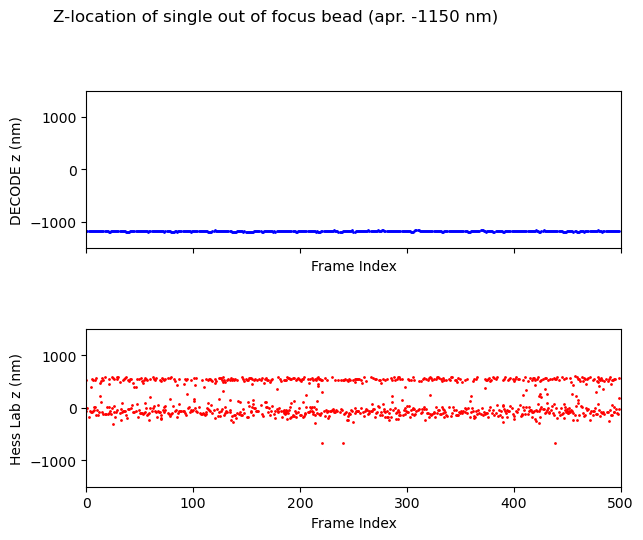

In [32]:
import matplotlib.pyplot as plt
import os

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(bead_points_decode[:, 0], bead_points_decode[:, 3], s=1, color='blue')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('DECODE z (nm)')
ax1.set_xlim(0, 500)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points_hesslab[:, 0], bead_points_hesslab[:, 3], s=1, color='red')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Hess Lab z (nm)')
ax2.set_xlim(0, 500)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-location of single out of focus bead (apr. -1150 nm)')
fig.savefig(os.path.join(fig_path, 'out_of_focus_bead_position.png'), dpi=300)

plt.tight_layout()
plt.show()



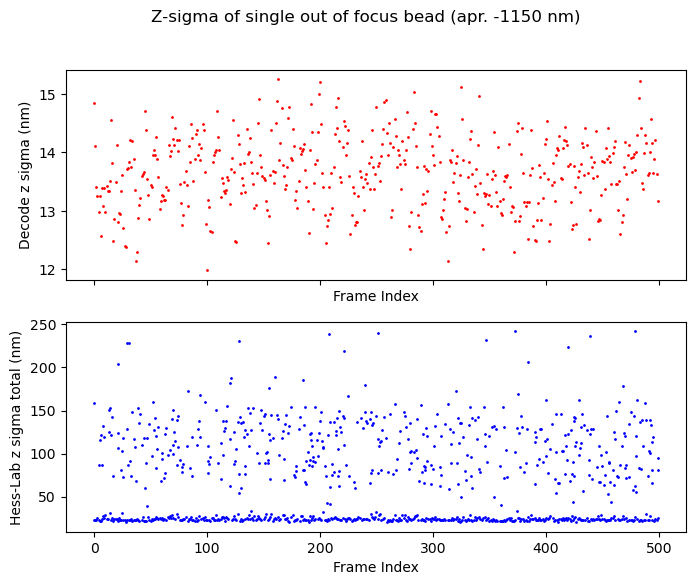

In [33]:
decode_emitters_roi = get_roi(em_sub, x_pos, y_pos, 20)
hesslab_emitters_roi = get_roi(hesslab_emitters, y_pos, x_pos, 20)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.scatter(decode_emitters_roi.frame_ix, decode_emitters_roi.xyz_sig[:,2], s=1, color='red')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('Decode z sigma (nm)')

ax2.scatter(hesslab_emitters_roi.frame_ix, hesslab_emitters_roi.xyz_sig[:,2], s=1, color='blue')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Hess-Lab z sigma total (nm)')

fig.suptitle('Z-sigma of single out of focus bead (apr. -1150 nm)')
fig.savefig(os.path.join(fig_path, 'out_of_focus_bead_sigma.png'), dpi=300)

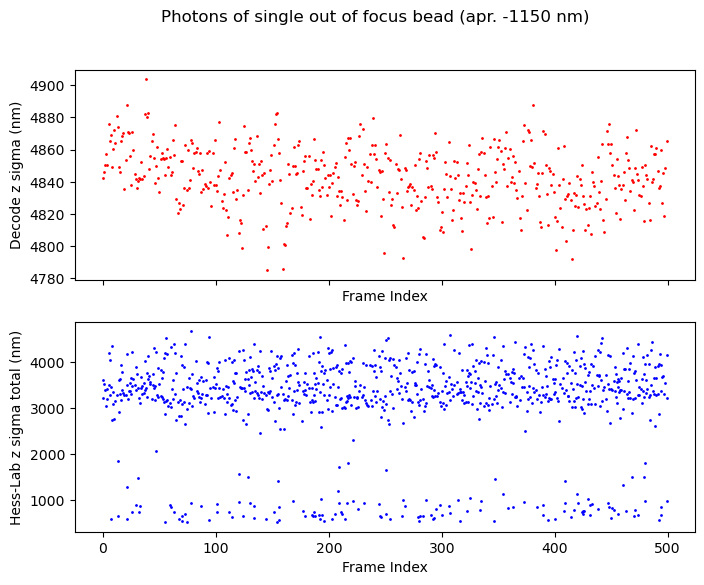

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.scatter(decode_emitters_roi.frame_ix, decode_emitters_roi.phot, s=1, color='red')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('Decode Photons')

ax2.scatter(hesslab_emitters_roi.frame_ix, hesslab_emitters_roi.phot, s=1, color='blue')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Hess-Lab Photons')

fig.suptitle('Photons of single out of focus bead (apr. -1150 nm)')
fig.savefig(os.path.join(fig_path, 'out_of_focus_bead_photons.png'), dpi=300)

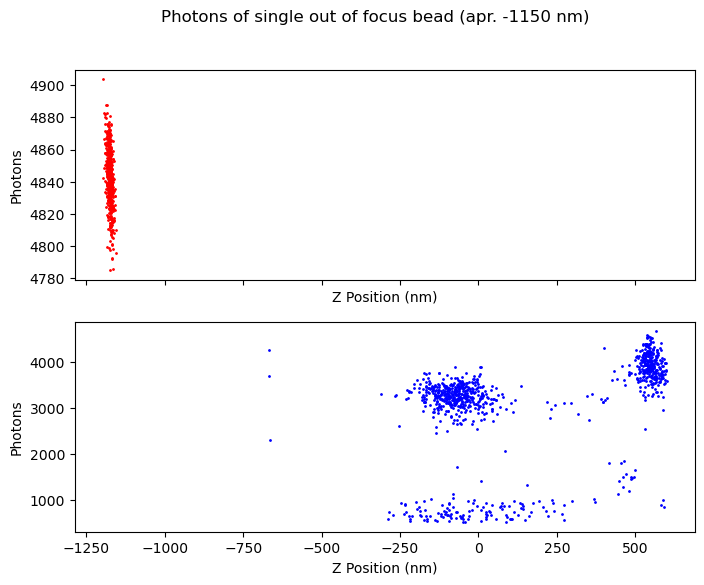

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.scatter(decode_emitters_roi.xyz_nm[:,2], decode_emitters_roi.phot, s=1, color='red')
ax1.set_xlabel('Z Position (nm)')
ax1.set_ylabel('Photons')

ax2.scatter(hesslab_emitters_roi.xyz_nm[:,2], hesslab_emitters_roi.phot, s=1, color='blue')
ax2.set_xlabel('Z Position (nm)')
ax2.set_ylabel('Photons')

fig.suptitle('Photons vs Z Position')
fig.savefig(os.path.join(fig_path, 'Photons_vs_z_positions.png'), dpi=300)

In [35]:
import torch
print(f'Decode mean z {torch.mean(decode_emitters_roi.xyz_nm[:,2])}')
print(f'Decode mean z sigma {torch.mean(decode_emitters_roi.xyz_sig[:,2])}')
print(f'Decode z sigma from data {torch.std(decode_emitters_roi.xyz_nm[:,2])}')
print(f'Hesslab mean z {torch.mean(hesslab_emitters_roi.xyz_nm[:,2])}')
print(f'Hesslab mean z sigma {torch.mean(hesslab_emitters_roi.xyz_sig[:,2])}')
print(f'Hesslab z sigma from data {torch.std(hesslab_emitters_roi.xyz_nm[:,2])}')

Decode mean z -1175.9310302734375
Decode mean z sigma 13.6505708694458
Decode z sigma from data 6.748907566070557
Hesslab mean z 157.0292043618421
Hesslab mean z sigma 69.17864111842106
Hesslab z sigma from data 301.5889902684031
